<div align="center"> <h3><font color='blue'>CSE 587 Data Intensive Computing Project Phase 1</font></h3>


In [1]:
!pip3 install wordcloud



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: pip3 install --upgrade pip


In [1]:
import pandas as pd
from collections import Counter  
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd
import re
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the CSV files
job_skills = pd.read_csv('job_skills.csv')
job_postings = pd.read_csv('linkedin_job_postings.csv')


In [4]:
job_summary = pd.read_csv('job_summary.csv')

In [5]:
# Display
print("**********************************************************")
print("Job Skills")
print("**********************************************************")
print(job_skills.info())  
print("**********************************************************")
print("Job Postings")
print("**********************************************************")
print(job_postings.info())
print("**********************************************************")
print("Job Summary")
print("**********************************************************")
print(job_summary.info())

**********************************************************
Job Skills
**********************************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296381 entries, 0 to 1296380
Data columns (total 2 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   job_link    1296381 non-null  object
 1   job_skills  1294296 non-null  object
dtypes: object(2)
memory usage: 19.8+ MB
None
**********************************************************
Job Postings
**********************************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1348454 entries, 0 to 1348453
Data columns (total 14 columns):
 #   Column               Non-Null Count    Dtype 
---  ------               --------------    ----- 
 0   job_link             1348454 non-null  object
 1   last_processed_time  1348454 non-null  object
 2   got_summary          1348454 non-null  object
 3   got_ner              1348454 non-null  ob

In [6]:
# Check missing values
print("**********************************************************")
print("Job Skills")
print("**********************************************************")
print(job_skills.isnull().sum(axis=0))  
print("**********************************************************")
print("Job Postings")
print("**********************************************************")
print(job_postings.isnull().sum(axis=0))
print("**********************************************************")
print("Job Summary")
print("**********************************************************")
print(job_summary.isnull().sum())  

**********************************************************
Job Skills
**********************************************************
job_link         0
job_skills    2085
dtype: int64
**********************************************************
Job Postings
**********************************************************
job_link                0
last_processed_time     0
got_summary             0
got_ner                 0
is_being_worked         0
job_title               0
company                11
job_location           19
first_seen              0
search_city             0
search_country          0
search_position         0
job_level               0
job_type                0
dtype: int64
**********************************************************
Job Summary
**********************************************************
job_link       0
job_summary    0
dtype: int64


In [7]:
# Summary statistics for numerical columns
print(job_postings.describe())  

                                                 job_link  \
count                                             1348454   
unique                                            1348454   
top     https://www.linkedin.com/jobs/view/on-demand-g...   
freq                                                    1   

                  last_processed_time got_summary  got_ner is_being_worked  \
count                         1348454     1348454  1348454         1348454   
unique                         722748           2        2               2   
top     2024-01-19 09:45:09.215838+00           t        t               f   
freq                           625540     1297877  1296401         1346978   

                      job_title          company  job_location  first_seen  \
count                   1348454          1348443       1348435     1348454   
unique                   584544            90605         29153           6   
top     LEAD SALES ASSOCIATE-FT  Health eCareers  New York, NY  2024-

In [8]:
# Unique job titles count 
print(f"Number of unique job titles:{job_postings["job_title"].nunique()}")
print(job_postings["job_title"].value_counts().head(10))

Number of unique job titles:584544
job_title
LEAD SALES ASSOCIATE-FT            7325
Shift Manager                      5818
First Year Tax Professional        5356
Assistant Manager                  5346
Customer Service Representative    5203
LEAD SALES ASSOCIATE-PT            4924
Store Manager                      4791
CUSTOMER SERVICE REPRESENTATIVE    4218
Registered Nurse                   4190
Hourly Supervisor & Training       2955
Name: count, dtype: int64


In [10]:
 # Extract most common skills  
allSkills = job_skills["job_skills"].dropna().str.split(",").explode()  
topSkills = Counter(allSkills).most_common(10)  
print("Top 10 skills")
print(topSkills)


Top 10 skills
[(' Communication', 356422), (' Teamwork', 223058), (' Leadership', 162949), (' Communication skills', 104735), (' Customer service', 104136), (' Problem Solving', 101751), (' Customer Service', 93468), (' Problemsolving', 92228), (' Collaboration', 86650), (' Training', 82882)]


In [11]:
#Remote vs. On-site Job Counts
job_postings['is_remote'] = job_postings['job_location'].apply(lambda x: 1 if 'remote' in str(x).lower() else 0)
print(job_postings['is_remote'].value_counts())


is_remote
0    1348454
Name: count, dtype: int64


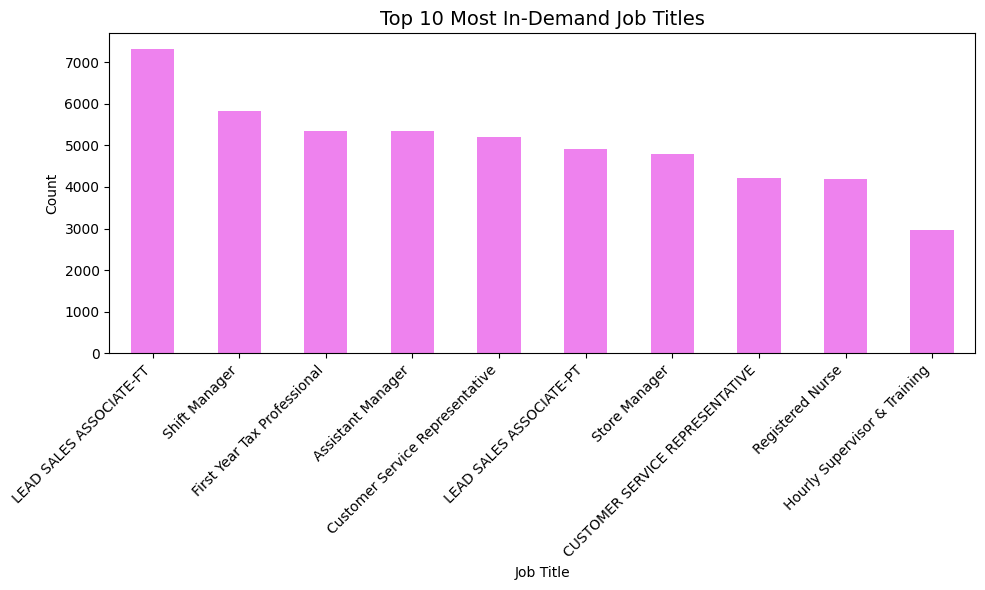

In [12]:
#Plot  of Top 10 Most In-Demand Job Titles

plt.figure(figsize=(10,6))
job_postings['job_title'].value_counts().head(10).plot(kind='bar', color='violet')

plt.title('Top 10 Most In-Demand Job Titles', fontsize=14)
plt.xlabel('Job Title')
plt.ylabel('Count')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


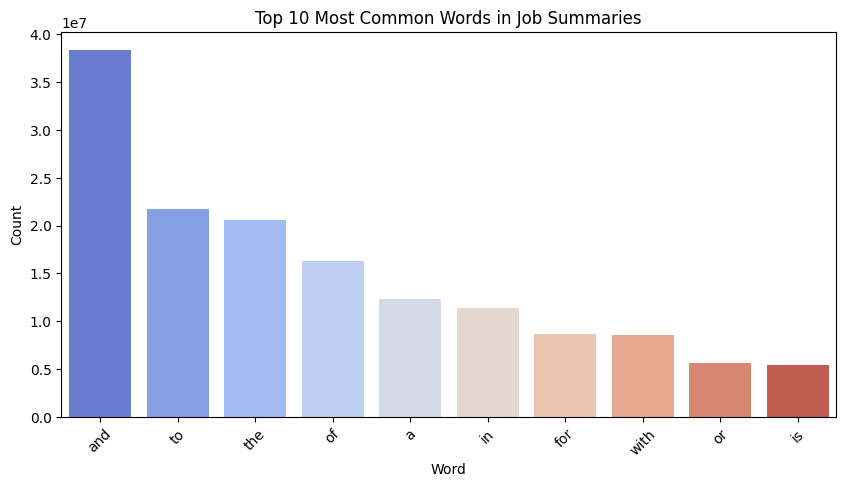

In [5]:
#Which words frequently appear in job summaries?
# Preprocess text
job_summary['clean_summary'] = job_summary['job_summary'].str.lower().str.replace(r'[^a-z\s]', '', regex=True)

# Tokenize and count word frequency
wordCounts = Counter(" ".join(job_summary['clean_summary']).split())

# Get most common words
df_wordCounts = pd.DataFrame(wordCounts.most_common(10), columns=['Word', 'Count'])

# Plot
plt.figure(figsize=(10,5))
sns.barplot(data=df_wordCounts, x='Word', y='Count', palette='coolwarm')
plt.title('Top 10 Most Common Words in Job Summaries')
plt.xlabel('Word')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


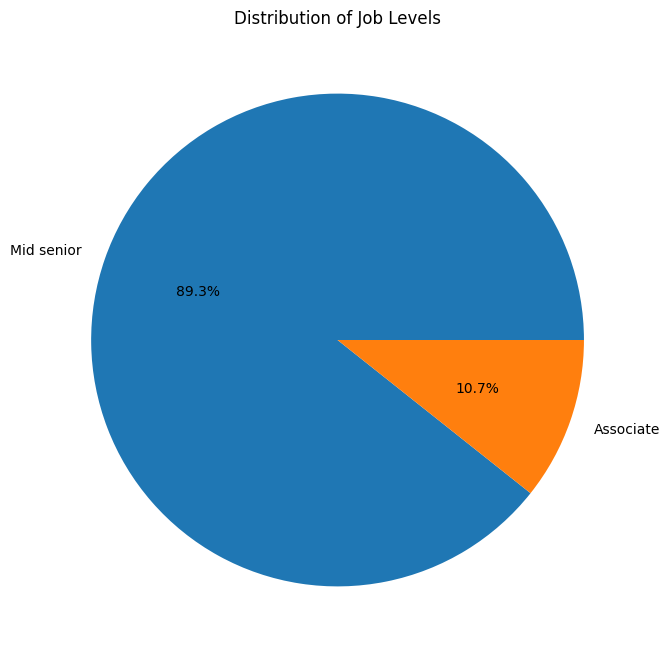

In [13]:
# Distribution of experience levels in Job Summary dataset
jobLevelDistribution = job_postings['job_level'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(jobLevelDistribution, labels=jobLevelDistribution.index, autopct='%1.1f%%')
plt.title("Distribution of Job Levels")
plt.show()

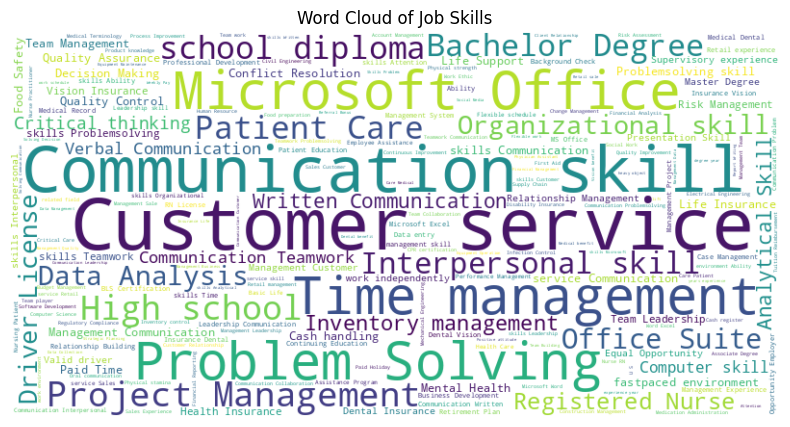

In [14]:
# Word cloud for job descriptions in Job Postings dataset

text = " ".join(job_skills['job_skills'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Job Skills")
plt.show()

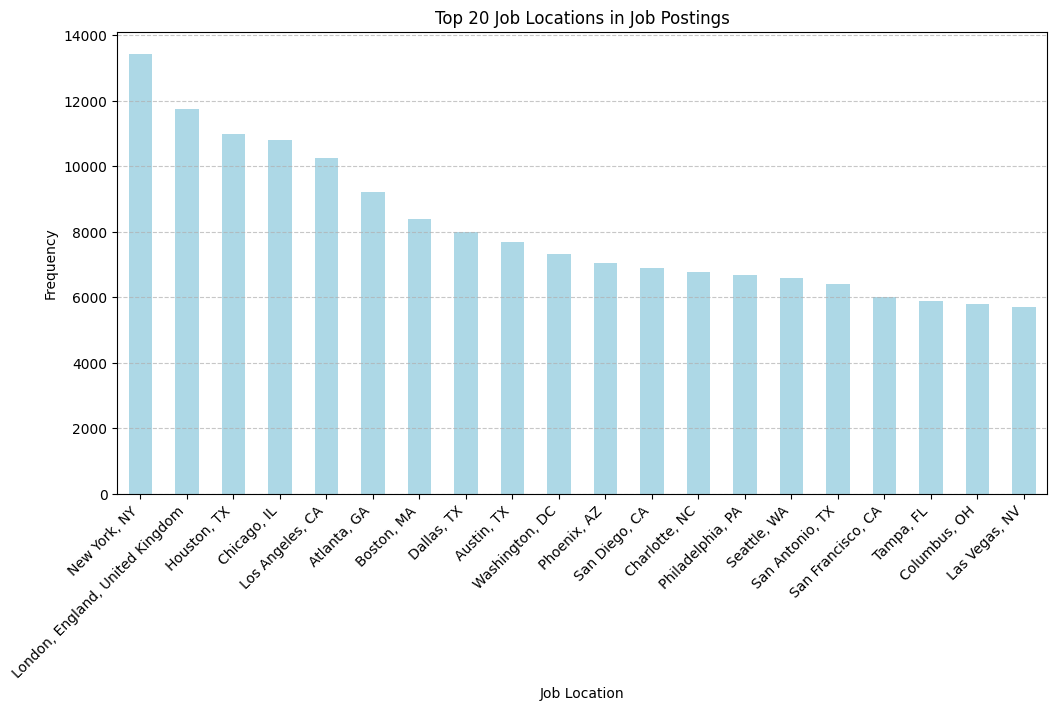

In [15]:
# Distribution of jobs across locations
locationCounts = job_postings['job_location'].dropna().value_counts().head(20)
plt.figure(figsize=(12, 6))
locationCounts.plot(kind='bar', color='lightblue')
plt.xlabel("Job Location")
plt.ylabel("Frequency")
plt.title("Top 20 Job Locations in Job Postings")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

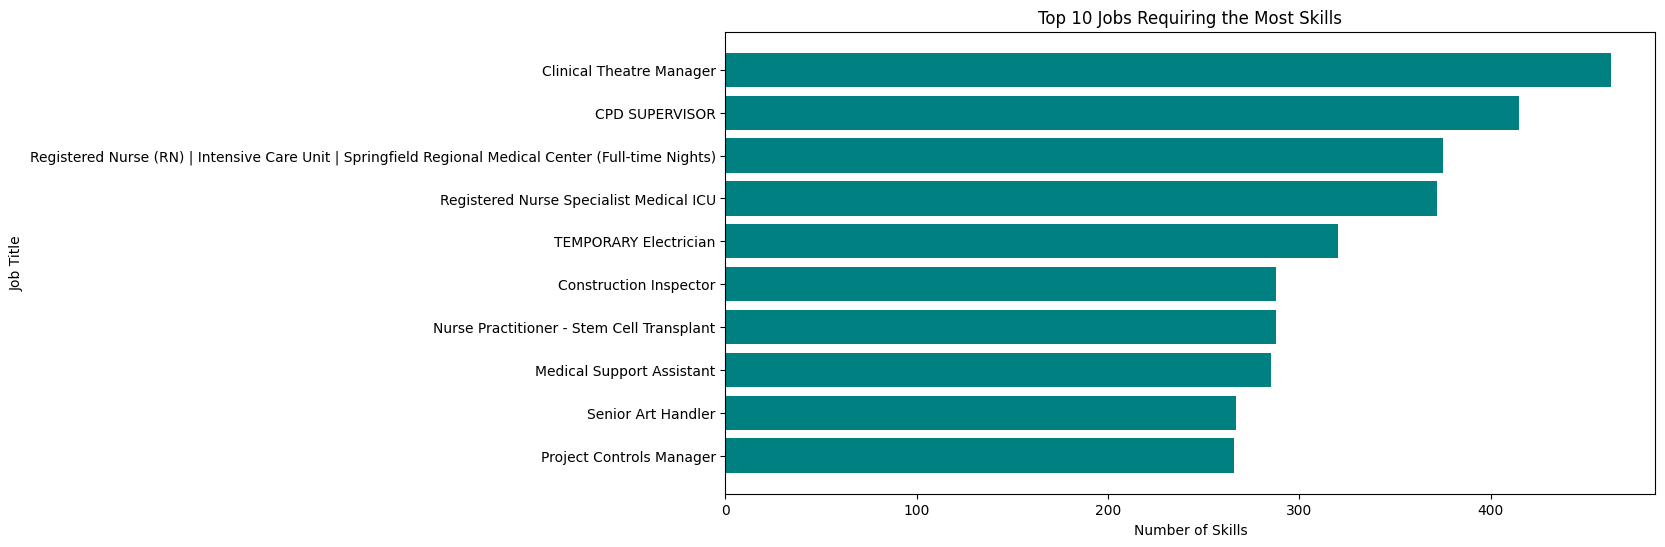

In [17]:
# Jobs and the number of skills they requuire

mergedDf = pd.merge(job_skills, job_postings[['job_link', 'job_title']], on='job_link', how='inner')
mergedDf['skill_count'] = mergedDf['job_skills'].apply(lambda x: len(str(x).split(',')))
topJobs = mergedDf.nlargest(10, 'skill_count')

plt.figure(figsize=(12, 6))
plt.barh(topJobs['job_title'], topJobs['skill_count'], color='teal')
plt.xlabel('Number of Skills')
plt.ylabel('Job Title')
plt.title('Top 10 Jobs Requiring the Most Skills')
plt.gca().invert_yaxis()
plt.show()
